<a href="https://colab.research.google.com/github/Ewanjohndennis/ML_LAB/blob/main/assignment7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment-7 — Week 1 September
## Learning Objective: Learn KNN Classifier

# 1. KNN Classification — Student Pass/Fail

## Problem Statement

A college wants to classify students into two categories, **Pass** and **Fail**, based on their **Study Hours** and **Attendance Percentage**.

### Dataset

| Student | Study Hours | Attendance (%) | Result |
|---|---:|---:|---|
| S1 | 2.0 | 55 | Fail |
| S2 | 2.5 | 60 | Fail |
| S3 | 3.0 | 58 | Fail |
| S4 | 3.5 | 65 | Fail |
| S5 | 4.0 | 70 | Pass |
| S6 | 4.5 | 72 | Pass |
| S7 | 5.0 | 75 | Pass |
| S8 | 5.5 | 78 | Pass |
| S9 | 6.0 | 80 | Pass |
| S10 | 6.5 | 82 | Pass |
| S11 | 7.0 | 85 | Pass |
| S12 | 3.0 | 75 | Pass |

### New Student

- **Study Hours:** 4.2
- **Attendance:** 68%

## Tasks

1. Represent the data using a Pandas DataFrame.
2. Separate the features and target variable.
3. Implement KNN manually:
   - Calculate Euclidean distance.
   - Sort samples by distance.
   - Select the K nearest neighbors.
   - Identify their classes.
   - Use majority voting for prediction.
4. Implement KNN using `KNeighborsClassifier`.
5. Compare manual and Scikit-learn predictions.
6. Repeat for `K = 5` and `K = 7`.
7. Plot the training samples and new student's position.
8. Standardize the features and repeat KNN classification.
9. Compare scaled and unscaled results.
10. Explain why feature scaling is important in KNN.
11. Calculate classification accuracy using a suitable train-test split.
12. Construct a confusion matrix.
13. Try `K = 1, 3, 5, 7, 9` and identify the K value with the best accuracy.


         Study Hours  Attendance Result  Distance
Student                                          
S5               4.0          70   Pass  2.009975
S4               3.5          65   Fail  3.080584
S6               4.5          72   Pass  4.011234
Manual Prediction for new student: Pass
Scikit-learn prediction for k= 3 : Pass
Scikit-learn prediction for k= 5 : Pass
Scikit-learn prediction for k= 7 : Pass


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


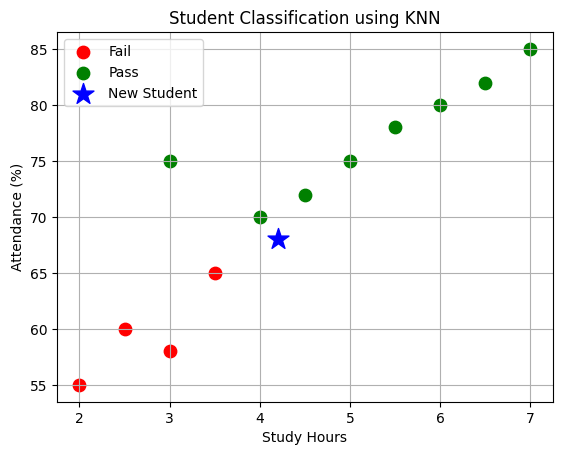

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Scikit-learn prediction for k= 3 : Pass
Scikit-learn prediction for k= 5 : Pass
Scikit-learn prediction for k= 7 : Pass
Best K: 1
Best Accuracy: 1.0


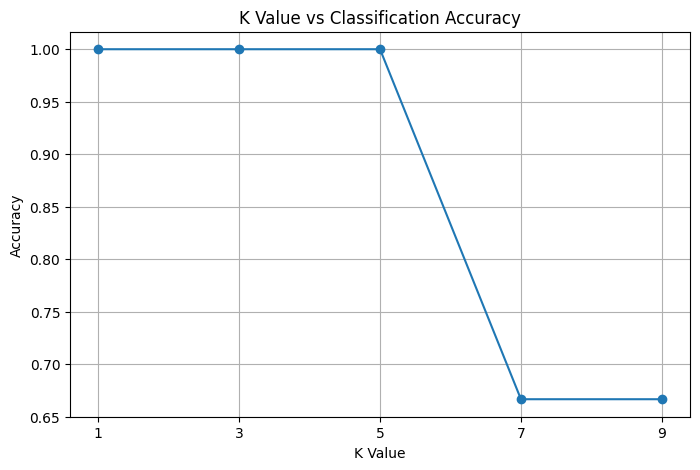

Confusion Matrix:
[[1 0]
 [0 2]]
Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         1
        Pass       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data = {
    'Student': ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12'],
    'Study Hours': [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 3.0],
    'Attendance': [55, 60, 58, 65, 70, 72, 75, 78, 80, 82, 85, 75],
    'Result': ['Fail', 'Fail', 'Fail', 'Fail', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass']
}

df = pd.DataFrame(data)
df.set_index('Student', inplace=True)
X=df[['Study Hours','Attendance']]
y=df['Result']
new_student=np.array([[4.2, 68]])
distances=[]
for i in range(len(X)):
  study_distance=(X.iloc[i]['Study Hours']-new_student[0][0])
  attend_distance=(X.iloc[i]['Attendance'] - new_student[0][1])
  distance=np.sqrt(study_distance**2 + attend_distance**2)
  distances.append(distance)
df['Distance']=distances
sorted_vals=df.sort_values(by='Distance')
k=3
neighbours=sorted_vals.head(k)
print(neighbours[['Study Hours', 'Attendance', 'Result', 'Distance']])
prediction = neighbours['Result'].mode()[0]
print("Manual Prediction for new student:", prediction)
for k in [3,5,7]:
  knn=KNeighborsClassifier(n_neighbors=k)
  knn.fit(X,y)
  sklearnpred=knn.predict(new_student)
  print("Scikit-learn prediction for k=",k, ":", sklearnpred[0])
for result, color in [('Fail', 'red'), ('Pass', 'green')]:
    subset = df[df['Result'] == result]

    plt.scatter(
        subset['Study Hours'],
        subset['Attendance'],
        color=color,
        label=result,
        s=80
    )
plt.scatter(
    4.2,
    68,
    color='blue',
    marker='*',
    s=250,
    label='New Student'
)
plt.xlabel('Study Hours')
plt.ylabel('Attendance (%)')
plt.title('Student Classification using KNN')
plt.legend()
plt.grid(True)
plt.show()
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
new_student_scaled=scaler.transform(new_student)
for k in [3,5,7]:
  knn_scaled=KNeighborsClassifier(n_neighbors=k)
  knn_scaled.fit(X_scaled,y)
  sklearnpred=knn_scaled.predict(new_student)
  print("Scikit-learn prediction for k=",k, ":", sklearnpred[0])
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
scalernew=StandardScaler()
X_train_scaled=scalernew.fit_transform(X_train)
X_test_scaled=scalernew.transform(X_test)
k_values = [1, 3, 5, 7, 9]

accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)
plt.figure(figsize=(8, 5))

plt.plot(k_values, accuracies, marker='o')

plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('K Value vs Classification Accuracy')
plt.xticks(k_values)
plt.grid(True)

plt.show()
best_knn = KNeighborsClassifier(n_neighbors=best_k)

best_knn.fit(X_train_scaled, y_train)

y_pred = best_knn.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(classification_report(y_test, y_pred))


# 2. KNN Classification — Breast Cancer Wisconsin Dataset

## Problem Statement

Use the built-in **Breast Cancer Wisconsin dataset** from Scikit-learn to build a KNN classifier for predicting whether a breast tumor is **malignant or benign**.

## Dataset

```python
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
````

 ## Tasks

 1. Load the dataset and create a Pandas DataFrame.
2. Display:
   - Number of samples and features
   - Feature names
   - Target names
   - Class distribution
   - Summary statistics
3. Separate the features `X` and target `y`.
4. Split the dataset into **80% training** and **20% testing** data.
5. Standardize the features using `StandardScaler`.
6. Create a `KNeighborsClassifier`.
7. Use `GridSearchCV` with **5-fold cross-validation**.
8. Test the following values of K:

```
K = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
```

 9. Display:
   - Best value of K
   - Best cross-validation accuracy
   - Test accuracy of the best model
10. Display:
    - Confusion matrix
    - Classification report
    - Precision
    - Recall
    - F1-score
11. Plot **K value vs. cross-validation accuracy**.
12. Identify the best K graphically.
13. Compare the performance of different K values.



Number of samples: 569
Number of features: 30

Feature Names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target Names:
['malignant' 'benign']

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64

Summary Statistics:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000



Best K: 3
Best Cross-Validation Accuracy: 0.9692
Test Accuracy: 0.9825
Precision Score: 0.973
Recall Score: 1.0
F1 Score: 0.9863

Confusion Matrix:
[[40  2]
 [ 0 72]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        42
           1       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



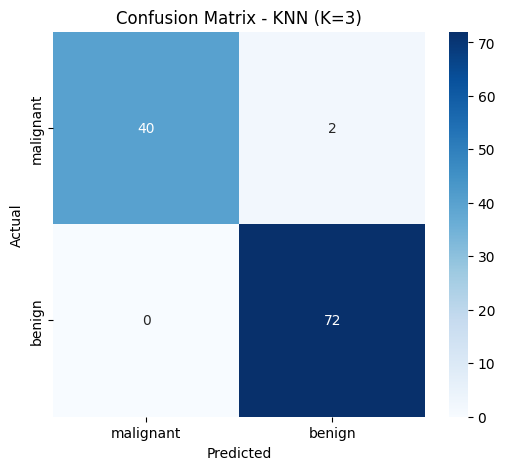


K vs Cross-Validation Accuracy:


,K,Cross-Validation Accuracy
0,1,0.945055
1,3,0.969231
2,5,0.967033
3,7,0.969231
4,9,0.969231
5,11,0.962637
6,13,0.958242
7,15,0.960440
8,17,0.958242
9,19,0.958242


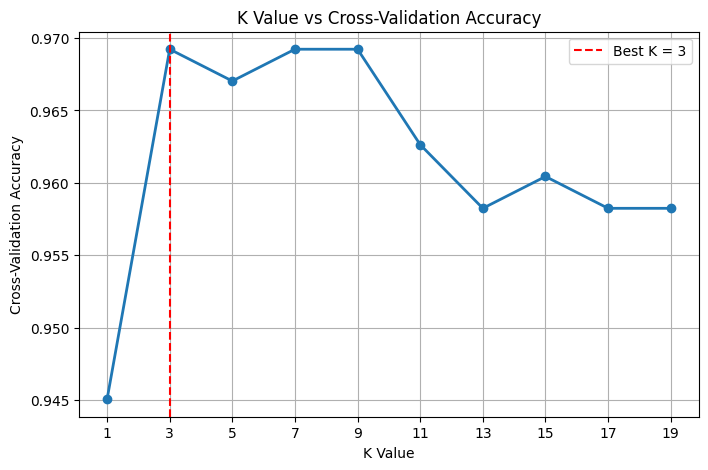

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

data=load_breast_cancer()
df=pd.DataFrame(data.data, columns=data.feature_names)
df['target']=data.target
print("\nNumber of samples:", data.data.shape[0])
print("Number of features:", data.data.shape[1])

print("\nFeature Names:")
print(data.feature_names)

print("\nTarget Names:")
print(data.target_names)

print("\nClass Distribution:")
print(df['target'].value_counts())

print("\nSummary Statistics:")
display(df.describe())

X=df.drop('target', axis=1)
y=df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state=42,stratify=y
)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
knn = KNeighborsClassifier()
k_values = [1,3,5,7,9,11,13,15,17,19]
param_grid = {'n_neighbors': k_values}
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)
grid_search.fit(X_train_scaled, y_train)
best_k = grid_search.best_params_['n_neighbors']
best_accuracy = grid_search.best_score_
print("\nBest K:", best_k)
print("Best Cross-Validation Accuracy:", round(best_accuracy, 4))
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", round(test_accuracy, 4))
print("Precision Score:", round(precision_score(y_test, y_pred),4))
print("Recall Score:", round(recall_score(y_test, y_pred),4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
cm=confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - KNN (K={best_k})')
plt.show()
cv_results = grid_search.cv_results_

k_results = cv_results['param_n_neighbors'].data.astype(int)
mean_scores = cv_results['mean_test_score']

results_df = pd.DataFrame({
    'K': k_results,
    'Cross-Validation Accuracy': mean_scores
})

print("\nK vs Cross-Validation Accuracy:")
display(results_df)
plt.figure(figsize=(8, 5))

plt.plot(
    results_df['K'],
    results_df['Cross-Validation Accuracy'],
    marker='o',
    linewidth=2
)

plt.axvline(
    best_k,
    color='red',
    linestyle='--',
    label=f'Best K = {best_k}'
)

plt.xlabel('K Value')
plt.ylabel('Cross-Validation Accuracy')
plt.title('K Value vs Cross-Validation Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.legend()

plt.show()


# 3\. KNN Image Classification — Fashion MNIST

 ## Problem Statement

 Implement the **K-Nearest Neighbors (KNN)** algorithm for image classification using the **Fashion MNIST** dataset.

 ## Tasks

 1. Load the Fashion MNIST dataset.
2. Preprocess the image data.
3. Convert/reshape images into suitable feature vectors for KNN.
4. Standardize or normalize the data where appropriate.
5. Split the dataset into training and testing sets.
6. Implement KNN for multi-class classification.
7. Experiment with different values of K.
8. Evaluate the model using suitable performance metrics.
9. Compare the accuracy for different K values.
10. Discuss the impact of K on:
    - Model accuracy
    - Overfitting and underfitting
    - Computational efficiency
11. Plot the performance of different K values.
12. Summarize the observations and identify the most suitable K.






29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)

Class Names:
0 -> T-shirt/top
1 -> Trouser
2 -> Pullover
3 -> Dress
4 -> Coat
5 -> Sandal
6 -> Shirt
7 -> Sneaker
8 -> Bag
9 -> Ankle boot


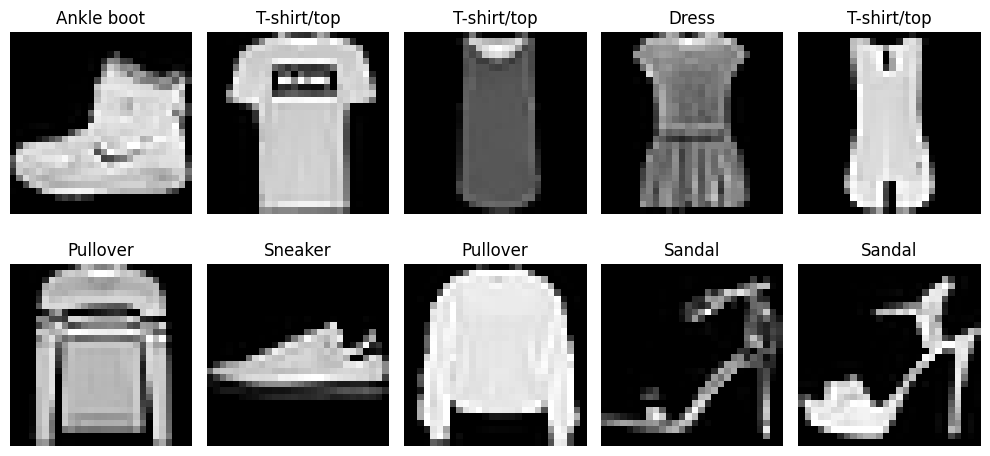


Flattened training data shape: (60000, 784)
Flattened testing data shape: (10000, 784)

KNN Training samples: 10000
KNN Testing samples: 2000

Training KNN with K = 1...
K = 1, Accuracy = 0.8075

Training KNN with K = 3...
K = 3, Accuracy = 0.8195

Training KNN with K = 5...
K = 5, Accuracy = 0.8225

Training KNN with K = 7...
K = 7, Accuracy = 0.8260

Training KNN with K = 9...
K = 9, Accuracy = 0.8220

BEST KNN RESULT
Best K: 7
Best Accuracy: 0.826


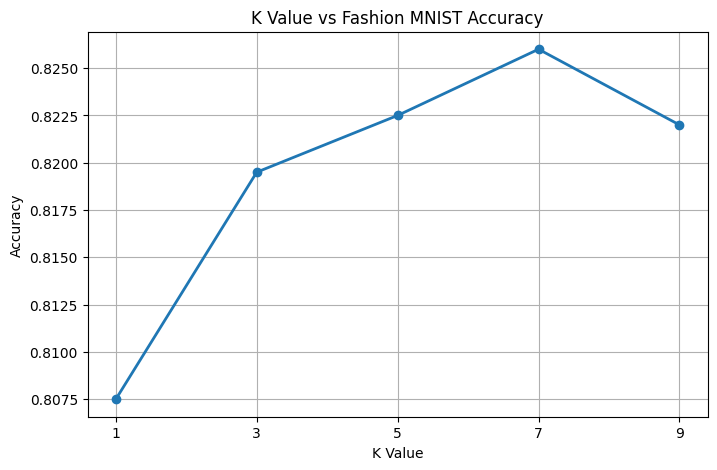

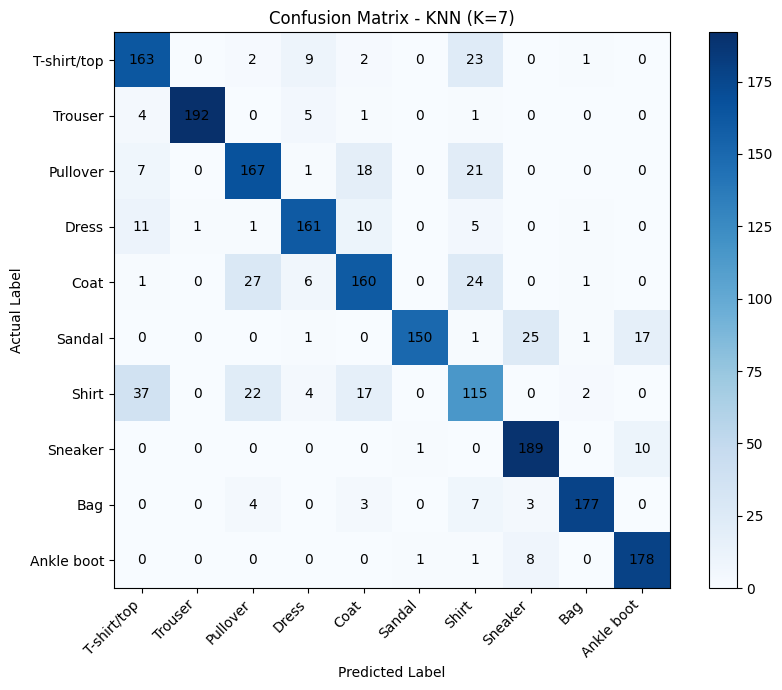


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.73      0.81      0.77       200
     Trouser       0.99      0.95      0.97       203
    Pullover       0.75      0.78      0.76       214
       Dress       0.86      0.85      0.85       190
        Coat       0.76      0.73      0.74       219
      Sandal       0.99      0.77      0.86       195
       Shirt       0.58      0.58      0.58       197
     Sneaker       0.84      0.94      0.89       200
         Bag       0.97      0.91      0.94       194
  Ankle boot       0.87      0.95      0.91       188

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



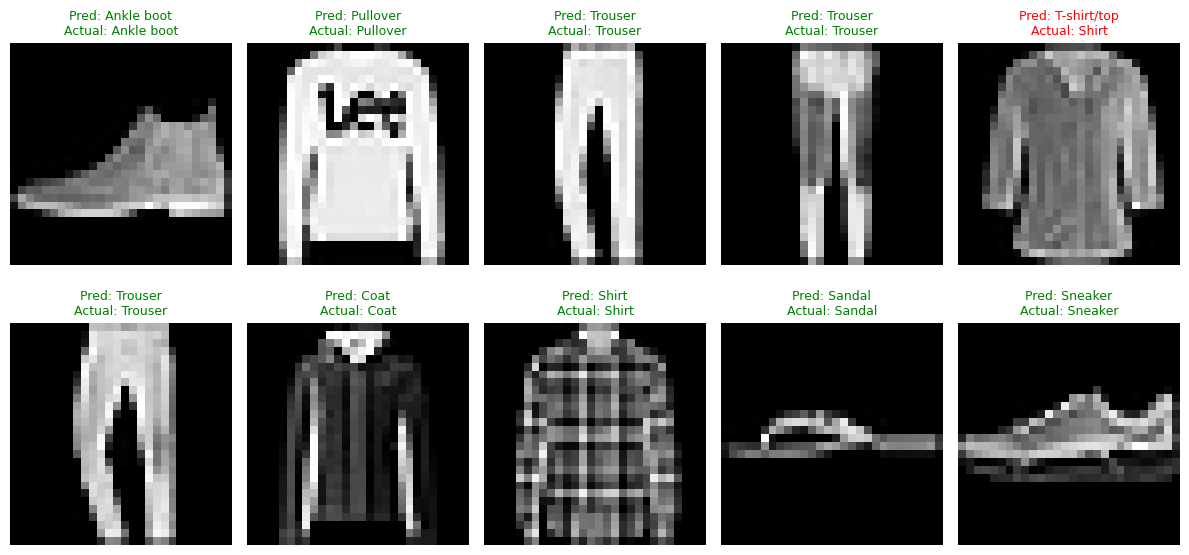


KNN Performance Comparison:


,K,Accuracy
0,1,0.8075
1,3,0.8195
2,5,0.8225
3,7,0.8260
4,9,0.8220


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

print("\nClass Names:")
for i, name in enumerate(class_names):
    print(i, "->", name)

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("\nFlattened training data shape:", X_train_flat.shape)
print("Flattened testing data shape:", X_test_flat.shape)

X_train_flat = X_train_flat.astype('float32') / 255.0
X_test_flat = X_test_flat.astype('float32') / 255.0

X_train_knn = X_train_flat[:10000]
y_train_knn = y_train[:10000]

X_test_knn = X_test_flat[:2000]
y_test_knn = y_test[:2000]

print("\nKNN Training samples:", X_train_knn.shape[0])
print("KNN Testing samples:", X_test_knn.shape[0])

k_values = [1, 3, 5, 7, 9]

accuracies = []

for k in k_values:
    print(f"\nTraining KNN with K = {k}...")

    knn = KNeighborsClassifier(
        n_neighbors=k,
        n_jobs=-1
    )

    knn.fit(X_train_knn, y_train_knn)

    y_pred = knn.predict(X_test_knn)

    accuracy = accuracy_score(y_test_knn, y_pred)

    accuracies.append(accuracy)

    print(f"K = {k}, Accuracy = {accuracy:.4f}")

best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print("\n===================================")
print("BEST KNN RESULT")
print("===================================")
print("Best K:", best_k)
print("Best Accuracy:", round(best_accuracy, 4))

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracies,
    marker='o',
    linewidth=2
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K Value vs Fashion MNIST Accuracy")
plt.xticks(k_values)
plt.grid(True)

plt.show()

best_knn = KNeighborsClassifier(
    n_neighbors=best_k,
    n_jobs=-1
)

best_knn.fit(X_train_knn, y_train_knn)

y_pred = best_knn.predict(X_test_knn)

cm = confusion_matrix(y_test_knn, y_pred)

plt.figure(figsize=(9, 7))

plt.imshow(cm, cmap='Blues')

plt.colorbar()

plt.xticks(
    range(10),
    class_names,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(10),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title(f"Confusion Matrix - KNN (K={best_k})")

for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.tight_layout()
plt.show()

print("\nClassification Report:")

print(
    classification_report(
        y_test_knn,
        y_pred,
        target_names=class_names
    )
)

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[i], cmap='gray')

    predicted_class = class_names[y_pred[i]]
    actual_class = class_names[y_test_knn[i]]

    color = 'green' if y_pred[i] == y_test_knn[i] else 'red'

    plt.title(
        f"Pred: {predicted_class}\nActual: {actual_class}",
        color=color,
        fontsize=9
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

results = pd.DataFrame({
    'K': k_values,
    'Accuracy': accuracies
})

print("\nKNN Performance Comparison:")
display(results)
